# Unusual density profiles: arrangement, not just the mean

Notebook 16 ended on a claim: a neutrino responds to how matter is *arranged* along its
path, not only to how much of it there is. This notebook makes that quantitative, with five
profiles that share the same mean density and the same total length and give completely
different probabilities.

It also isolates one arrangement that is **not** free to matter. Reversing a profile
end-to-end leaves every probability untouched -- but only when the Hamiltonian is complex
symmetric, which for three flavors means $\delta_{\rm CP} = 0$ or $\pi$. That distinction
turns out to be exact, measurable at the $10^{-16}$ level, and is the reason Mag$\nu$s can
halve the Hamiltonian evaluations on an Earth chord.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.globaldefs as gd
import magnus.plotting as plotting

OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
osc = OSC

## 1. Five profiles, one mean density

Each profile is eight equal-width slabs across 6000 km. The densities are drawn from
$\{1, 9\}$ g cm$^{-3}$ or held at the mean, 5 g cm$^{-3}$ -- so every profile below has the
same mean density and the same integrated column depth.

Slab edges are density **jumps**, so they are passed as `t_breakpoints`. A slab of the
integrator straddling a jump is not fixed by refinement, at any tolerance.

In [3]:
TOTAL_KM = 6000.0
LOW, HIGH, MEAN = 1.0, 9.0, 5.0

PROFILES = {
    'constant'          : [MEAN]*8,
    'castle  LHLHLHLH'  : [LOW, HIGH]*4,
    'reversed HLHLHLHL' : [HIGH, LOW]*4,
    'segregated LLLLHHHH': [LOW]*4 + [HIGH]*4,
    'segregated HHHHLLLL': [HIGH]*4 + [LOW]*4,
}

for name, rho in PROFILES.items():
    print('%-21s mean = %.3f g/cm^3' % (name, np.mean(rho)))

constant              mean = 5.000 g/cm^3
castle  LHLHLHLH      mean = 5.000 g/cm^3
reversed HLHLHLHL     mean = 5.000 g/cm^3
segregated LLLLHHHH   mean = 5.000 g/cm^3
segregated HHHHLLLL   mean = 5.000 g/cm^3


In [4]:
def build_H(densities, dim, h_vac_energy_indep):
    """A piecewise-constant matter Hamiltonian, plus the slab edges to declare."""
    n = len(densities)
    edges_km = np.arange(n + 1)*(TOTAL_KM/n)
    vcc = np.array([matter.vcc_func_from_rho_func(
        float(r), density_matter_is_in_g_per_cm3=True) for r in densities])   # [eV]

    def H(l, energy):
        i = int(np.clip(np.searchsorted(edges_km, l/gd.CONV_KM_TO_INV_EV,
                                        side='right') - 1, 0, n - 1))
        m = np.zeros((dim, dim))
        m[0][0] = vcc[i]
        return h_vac_energy_indep/energy + m

    return H, edges_km*gd.CONV_KM_TO_INV_EV


def scan(densities, energies, dim, h_vac, nu_i, nu_f, **kwargs):
    H, breakpoints = build_H(densities, dim, h_vac)
    L = TOTAL_KM*gd.CONV_KM_TO_INV_EV
    return np.array([oscprob.osc_prob(lambda l, e=e: H(l, e), 0.0, L,
                                      t_breakpoints=breakpoints, **kwargs)[nu_i][nu_f]
                     for e in energies])

## 2. The probabilities they produce

Two flavors first, in the atmospheric sector, muon-neutrino survival.

In [5]:
h2 = np.asarray(hamiltonians.hamiltonian_2nu_vacuum_energy_independent(
    osc['s23'], osc['D31']))

E_gev = np.logspace(-0.7, 1.7, 120)
E = E_gev*gd.UNIT_GEV

survival = {name: scan(rho, E, 2, h2, gd.NUMU, gd.NUMU)
            for name, rho in PROFILES.items()}
reference = survival['constant']

print('%-21s %14s %8s' % ('profile', 'max |P - P_const|', 'rms'))
print('-'*46)
for name, p in survival.items():
    print('%-21s %14.4f %8.4f'
          % (name, np.max(np.abs(p - reference)), np.sqrt(np.mean((p - reference)**2))))

/home/mbustamante/Research/magnus/src/magnus/magnus.py:551: ScalarHamiltonianWarning: magnus: the Hamiltonian could not be evaluated for several positions at once, so it is being called one position at a time. This is correct but slower -- measured 4.6x on a 3nu exponential-density profile -- because the engine samples the Hamiltonian at every quadrature node of every slab, and the adaptive refinement repeats that at each level. To take the fast path, write H_func so that it accepts an array of positions and returns a stack of matrices: turn the position dependence into NumPy operations and broadcast the matrix part, e.g. 'VCC[..., None, None]*e00' instead of 'VCC*e00'. A Hamiltonian that ignores its argument is detected separately and never triggers this. Shown once per session.
  _, mode = _evaluate_A(A, times, None)
/home/mbustamante/Research/magnus/src/magnus/magnus.py:1790: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series

profile               max |P - P_const|      rms
----------------------------------------------
constant                      0.0000   0.0000
castle  LHLHLHLH              0.9829   0.1589
reversed HLHLHLHL             0.9829   0.1589
segregated LLLLHHHH           0.6591   0.2413
segregated HHHHLLLL           0.6591   0.2413


The castle wall departs from the constant-density answer by **0.98** in probability --
essentially the entire available range -- while carrying exactly the same amount of matter.
Averaging the density first is not a mild approximation here; it is a different problem.

And the two rearrangements differ from each other, not merely from the mean:

In [6]:
print('castle LHLHLHLH vs segregated LLLLHHHH : max |diff| = %.4f'
      % np.max(np.abs(survival['castle  LHLHLHLH']
                      - survival['segregated LLLLHHHH'])))

i = int(np.argmax(np.abs(survival['castle  LHLHLHLH'] - reference)))
print('\nat E = %.2f GeV:' % E_gev[i])
for name, p in survival.items():
    print('   %-21s P = %.4f' % (name, p[i]))

castle LHLHLHLH vs segregated LLLLHHHH : max |diff| = 0.9514

at E = 1.54 GeV:
   constant              P = 0.9999
   castle  LHLHLHLH      P = 0.0170
   reversed HLHLHLHL     P = 0.0170
   segregated LLLLHHHH   P = 0.9684
   segregated HHHHLLLL   P = 0.9684


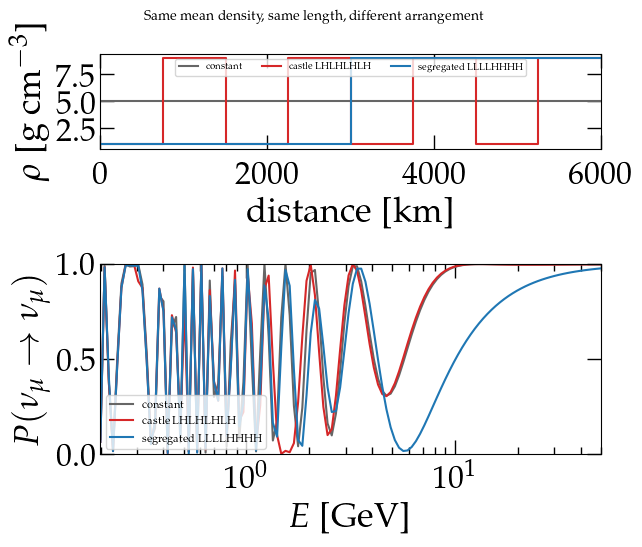

In [7]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(6.8, 5.6),
                               gridspec_kw=dict(height_ratios=[1, 2]))

edges = np.arange(9)*(TOTAL_KM/8)
for name, color in (('constant', '0.4'), ('castle  LHLHLHLH', 'C3'),
                    ('segregated LLLLHHHH', 'C0')):
    ax0.step(edges, np.append(PROFILES[name], PROFILES[name][-1]),
             where='post', color=color, label=name)
ax0.set_ylabel(r'$\rho$ [g cm$^{-3}$]')
ax0.set_xlabel('distance [km]')
ax0.set_xlim(0.0, TOTAL_KM)
ax0.legend(fontsize=7, ncol=3, loc='upper center')

for name, color in (('constant', '0.4'), ('castle  LHLHLHLH', 'C3'),
                    ('segregated LLLLHHHH', 'C0')):
    ax1.semilogx(E_gev, survival[name], color=color, label=name)
ax1.set_xlabel(r'$E$ [GeV]')
ax1.set_ylabel(r'$P(\nu_\mu \to \nu_\mu)$')
ax1.set_xlim(E_gev[0], E_gev[-1])
ax1.set_ylim(0.0, 1.0)
ax1.legend(fontsize=8, loc='lower left')
fig.suptitle('Same mean density, same length, different arrangement', fontsize=10)
fig.tight_layout()

## 3. The one rearrangement that changes nothing

Look again at the table in section 2: `castle LHLHLHLH` and `reversed HLHLHLHL` have
identical entries, as do the two segregated profiles. That is not a coincidence and not a
rounding accident -- it is exact.

Reversing a profile end-to-end maps the evolution operator to its transpose *provided each
slab Hamiltonian is complex symmetric*, $\mathbf{H}^{T} = \mathbf{H}$. Then
$P_{\rm reversed}(\nu_\alpha \to \nu_\beta) = P(\nu_\beta \to \nu_\alpha)$, and survival
probabilities are invariant outright.

For two flavors the Hamiltonian is real, hence symmetric, and this always holds:

In [8]:
castle = PROFILES['castle  LHLHLHLH']
print('2nu, castle vs its own reversal: max |diff| = %.2e'
      % np.max(np.abs(scan(castle, E, 2, h2, gd.NUMU, gd.NUMU)
                      - scan(castle[::-1], E, 2, h2, gd.NUMU, gd.NUMU))))

/home/mbustamante/Research/magnus/src/magnus/magnus.py:551: ScalarHamiltonianWarning: magnus: the Hamiltonian could not be evaluated for several positions at once, so it is being called one position at a time. This is correct but slower -- measured 4.6x on a 3nu exponential-density profile -- because the engine samples the Hamiltonian at every quadrature node of every slab, and the adaptive refinement repeats that at each level. To take the fast path, write H_func so that it accepts an array of positions and returns a stack of matrices: turn the position dependence into NumPy operations and broadcast the matrix part, e.g. 'VCC[..., None, None]*e00' instead of 'VCC*e00'. A Hamiltonian that ignores its argument is detected separately and never triggers this. Shown once per session.
  _, mode = _evaluate_A(A, times, None)
/home/mbustamante/Research/magnus/src/magnus/magnus.py:1790: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series

2nu, castle vs its own reversal: max |diff| = 8.88e-16


For **three** flavors the vacuum Hamiltonian is Hermitian, but it is only *symmetric*
when $\delta_{\rm CP}$ is $0$ or $\pi$ -- a nonzero CP phase puts genuine complex numbers off
the diagonal. So the reversal symmetry is exactly as good as CP conservation:

In [9]:
segregated = PROFILES['segregated LLLLHHHH']
E_one = 3.0*gd.UNIT_GEV

print('%-10s %-12s %-14s %s' % ('dCP', 'H symmetric', '|P_aa - Prev_aa|', '|P - Prev^T|'))
print('-'*56)
for dcp in (0.0, np.pi, OSC['dCP']):
    h3 = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
        **dict(OSC, dCP=dcp)))
    H_f, bp = build_H(segregated, 3, h3)
    H_r, _ = build_H(segregated[::-1], 3, h3)
    L = TOTAL_KM*gd.CONV_KM_TO_INV_EV
    A = np.asarray(oscprob.osc_prob(lambda l: H_f(l, E_one), 0.0, L, t_breakpoints=bp))
    B = np.asarray(oscprob.osc_prob(lambda l: H_r(l, E_one), 0.0, L, t_breakpoints=bp))
    print('%-10.4f %-12s %-14.2e %.2e'
          % (dcp, np.allclose(h3, h3.T),
             np.max(np.abs(np.diag(A) - np.diag(B))), np.max(np.abs(A - B.T))))

dCP        H symmetric  |P_aa - Prev_aa| |P - Prev^T|
--------------------------------------------------------
0.0000     True         3.33e-16       3.33e-16
3.1416     True         2.22e-16       2.22e-16
3.7001     False        2.37e-02       2.86e-02


Sixteen orders of magnitude separate the CP-conserving rows from the last one. The
symmetry is not approximately true and then slightly broken -- it is exact, and then absent.

**Why this matters to Mag$\nu$s.** A chord through a spherically symmetric Earth meets every
radius twice: the density profile *is* a palindrome. Mag$\nu$s exploits that by evaluating the
Hamiltonian on the first half of the slab chain and obtaining the rest by reversal, which
halves the calls to your `H_func`. It is worth 1.4--1.67x on an expensive Hamiltonian and
about 0.91x on plain PREM, where a density lookup is too cheap to be worth halving.
`magnus.magnus.USE_PALINDROME` disarms it. Notebook 24 measures this.

Note that the optimization reuses *evaluations of the profile*, which is valid whatever
$\delta_{\rm CP}$ is -- it does not assume the probability-level symmetry explored above.

## 4. A caution about `t_breakpoints`

Every profile in this notebook declared its slab edges, and it was the right thing to do: on a
**scan** across energies, breakpoints at genuine discontinuities are an established cure.

They are not a free win at a **single** point. Measured across 18 supernova-shock
configurations, adding breakpoints improved 7, worsened 11, and pushed 2 answers from inside
the requested tolerance to outside it. Notebook 14 has that measurement in full, and
`recipes.rst` states the rule. Declare breakpoints because you know where the discontinuities
are -- not as a general accuracy knob.

## Summary

| comparison | max $|\Delta P|$ |
|---|---|
| castle wall vs constant, same mean | **0.98** |
| segregated vs constant, same mean | 0.66 |
| castle vs segregated, same eight slabs | 0.95 |
| any profile vs its own reversal, $2\nu$ | $0$ (exact) |
| $3\nu$, $\delta_{\rm CP} = 0$ or $\pi$ | $\sim 10^{-16}$ (exact) |
| $3\nu$, $\delta_{\rm CP} = 3.70$ | $2.8\times10^{-2}$ |

The mean density tells you almost nothing. The order of the slabs tells you almost everything
-- except for the single reversal that CP conservation protects.

---

**Previous:** [Mass ordering and the octant](17_magnus_ordering_and_octant.ipynb)  
**Next:** [Bring your own Hamiltonian](19_magnus_custom_hamiltonian.ipynb) --- the contract, the vectorization trick, and what the Earth declares for you  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)